# Pipeline 3: Social Media Donation Conversion

## Problem framing

**Business question:** What post characteristics drive donation referrals, and can we predict a post's conversion value before publishing?

**Unit of analysis:** One row per social media post (N≈812).

**Targets:**
- Predictive: `donation_referrals` modeled as `log_referrals = log1p(donation_referrals)`.
- Explanatory: `estimated_donation_value_php` modeled as `log_value = log1p(estimated_donation_value_php)`.

**Predictive goal:** Pre-publication content planning model (RMSE, R²; random split and time split).

**Explanatory goal:** OLS on log value with platform fixed effects and interpretable content features.

**Leakage exclusions from predictive features:**
`impressions, reach, likes, comments, shares, saves, click_throughs, video_views, engagement_rate, profile_visits, watch_time_seconds, avg_view_duration_seconds, forwards`

**Causal note:** All explanatory findings are associative, not causal.


This model does two things. First, before a post goes live, it predicts how many donation referrals that post is likely to get. Second, it helps explain which post choices are linked to higher donation value, like platform, post type, CTA, timing, and whether a resident story is included. It is best used as a planning guide (which posts are more likely to perform better), not as an exact per-post guarantee, because many posts get zero referrals and the data is uneven. These results show associations, not proof of cause-and-effect, and the ImpactStory × ShareStory pattern is helpful but still uncertain because the sample for that combo is small.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

plt.savefig = lambda *args, **kwargs: None

from pathlib import Path
import os

def _resolve_data_path():
    env_path = os.getenv('LIGHTHOUSE_DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'lighthouse_csv_v7'
        if candidate.exists():
            return candidate

    fallback = Path('/Users/marycatherineshepherd/Documents/lighthouse_csv_v7')
    if fallback.exists():
        return fallback

    raise FileNotFoundError(
        "Could not locate 'lighthouse_csv_v7'. Set LIGHTHOUSE_DATA_PATH or place the folder in project/parent directories."
    )

DATA_PATH = str(_resolve_data_path()) + '/'



def _safe_read_csv(filename, parse_dates=None, required_cols=None, default_map=None):
    df = pd.read_csv(DATA_PATH + filename)
    required_cols = required_cols or []
    default_map = default_map or {}

    missing_cols = []
    for c in required_cols:
        if c not in df.columns:
            df[c] = default_map.get(c, np.nan)
            missing_cols.append(c)

    for c, v in default_map.items():
        if c in df.columns:
            df[c] = df[c].fillna(v)

    missing_date_cols = []
    if parse_dates:
        for c in parse_dates:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
            else:
                missing_date_cols.append(c)

    if missing_cols:
        print(f"[Schema] {filename}: added missing columns -> {missing_cols}")
    if missing_date_cols:
        print(f"[Schema] {filename}: skipped missing date columns -> {missing_date_cols}")

    return df


# --- Data Cleaning Audit (Thoroughness Report) ---
def _cleaning_audit(df_map):
    rows = []
    for name, frame in df_map.items():
        miss = int(frame.isna().sum().sum())
        miss_pct = float((frame.isna().mean().mean() * 100) if len(frame.columns) else 0)
        rows.append({
            'table': name,
            'rows': int(len(frame)),
            'cols': int(frame.shape[1]),
            'total_missing_cells': miss,
            'avg_missing_pct_across_cols': round(miss_pct, 2)
        })
    rep = pd.DataFrame(rows).sort_values('table')
    print(rep)
    return rep


In [2]:
posts = _safe_read_csv('social_media_posts.csv', required_cols=['post_id','created_at','platform','post_type','media_type','sentiment_tone','content_topic','has_call_to_action','call_to_action_type','is_boosted','boost_budget_php','num_hashtags','caption_length','features_resident_story','campaign_name','donation_referrals','estimated_donation_value_php'])
donations = _safe_read_csv('donations.csv', required_cols=['donation_id','donation_date','referral_post_id','amount'])

# Ensure expected columns exist
required_post_cols = [
    'post_id', 'created_at', 'platform', 'post_type', 'media_type', 'sentiment_tone',
    'content_topic', 'has_call_to_action', 'call_to_action_type', 'is_boosted',
    'boost_budget_php', 'num_hashtags', 'caption_length', 'features_resident_story',
    'campaign_name', 'donation_referrals', 'estimated_donation_value_php'
]
for c in required_post_cols:
    if c not in posts.columns:
        posts[c] = np.nan

required_donation_cols = ['donation_id', 'donation_date', 'referral_post_id', 'amount']
for c in required_donation_cols:
    if c not in donations.columns:
        donations[c] = np.nan

# Parse and coerce key fields
posts['created_at'] = pd.to_datetime(posts['created_at'], errors='coerce')
donations['donation_date'] = pd.to_datetime(donations['donation_date'], errors='coerce')
posts['post_id'] = pd.to_numeric(posts['post_id'], errors='coerce')
donations['referral_post_id'] = pd.to_numeric(donations['referral_post_id'], errors='coerce')
donations['amount'] = pd.to_numeric(donations['amount'], errors='coerce').fillna(0)

posts['donation_referrals'] = pd.to_numeric(posts['donation_referrals'], errors='coerce').fillna(0)
posts['estimated_donation_value_php'] = pd.to_numeric(posts['estimated_donation_value_php'], errors='coerce').fillna(0)
posts['boost_budget_php'] = pd.to_numeric(posts['boost_budget_php'], errors='coerce')
posts['num_hashtags'] = pd.to_numeric(posts['num_hashtags'], errors='coerce')
posts['caption_length'] = pd.to_numeric(posts['caption_length'], errors='coerce')

for bcol in ['has_call_to_action', 'is_boosted', 'features_resident_story']:
    posts[bcol] = posts[bcol].astype(str).str.lower().map({
        'true': 1, 'false': 0, '1': 1, '0': 0, 'yes': 1, 'no': 0
    })

ref_from_don = (
    donations[donations['referral_post_id'].notna()]
    .groupby('referral_post_id', as_index=False)
    .agg(
        donation_referrals_from_donations=('donation_id', 'count'),
        donation_value_from_donations=('amount', 'sum')
    )
    .rename(columns={'referral_post_id': 'post_id'})
)

posts = posts.merge(ref_from_don, on='post_id', how='left')
for c in ['donation_referrals_from_donations', 'donation_value_from_donations']:
    if c not in posts.columns:
        posts[c] = 0
posts[['donation_referrals_from_donations', 'donation_value_from_donations']] = posts[[
    'donation_referrals_from_donations', 'donation_value_from_donations'
]].fillna(0)

df = posts.copy()
df['log_referrals'] = np.log1p(df['donation_referrals'].clip(lower=0))
df['log_value'] = np.log1p(df['estimated_donation_value_php'].clip(lower=0))

df['day_of_week'] = df['created_at'].dt.day_name().fillna('Unknown')
df['post_hour'] = pd.to_numeric(df['created_at'].dt.hour, errors='coerce').fillna(12).astype(int)

df['platform'] = df['platform'].fillna('Unknown').astype(str)
df['post_type'] = df['post_type'].fillna('Unknown').astype(str)
df['media_type'] = df['media_type'].fillna('Unknown').astype(str)
df['sentiment_tone'] = df['sentiment_tone'].fillna('Unknown').astype(str)
df['content_topic'] = df['content_topic'].fillna('Unknown').astype(str)
df['call_to_action_type'] = df['call_to_action_type'].fillna('Unknown').astype(str)

df['is_peak_hour'] = df['post_hour'].isin([8, 9, 10, 19, 20]).astype(int)
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df['cta_is_donate'] = (df['call_to_action_type'] == 'DonateNow').astype(int)
df['campaign_active'] = df['campaign_name'].notna().astype(int)
df['platform_is_whatsapp'] = (df['platform'] == 'WhatsApp').astype(int)
df['is_impact_story_share_combo'] = ((df['post_type'] == 'ImpactStory') & (df['call_to_action_type'] == 'ShareStory')).astype(int)

if df['created_at'].notna().any():
    df = df.sort_values(['platform', 'created_at'])
    df['days_since_last_platform_post'] = df.groupby('platform')['created_at'].diff().dt.days.fillna(999).clip(lower=0)
    df = df.sort_values('created_at').reset_index(drop=True)
else:
    df = df.reset_index(drop=True)
    df['days_since_last_platform_post'] = 999

leakage_features = [
    'impressions', 'reach', 'likes', 'comments', 'shares', 'saves',
    'click_throughs', 'video_views', 'engagement_rate', 'profile_visits',
    'watch_time_seconds', 'avg_view_duration_seconds', 'forwards'
]

predictive_features = [
    'platform', 'post_type', 'media_type', 'sentiment_tone', 'content_topic',
    'has_call_to_action', 'call_to_action_type', 'is_boosted', 'boost_budget_php',
    'num_hashtags', 'caption_length', 'post_hour', 'day_of_week',
    'features_resident_story', 'campaign_active', 'is_peak_hour', 'is_weekend',
    'cta_is_donate', 'is_impact_story_share_combo', 'platform_is_whatsapp',
    'days_since_last_platform_post'
]

X = df[predictive_features].copy()
y = pd.to_numeric(df['log_referrals'], errors='coerce').fillna(0).astype(float)

print('rows', len(df))
print('zero_referral_share', round((df['donation_referrals'] == 0).mean(), 3))


rows 812
zero_referral_share 0.357


In [3]:
CLEANING_AUDIT = _cleaning_audit({'posts': posts, 'donations': donations, 'model_df': df})


       table  rows  cols  total_missing_cells  avg_missing_pct_across_cols
1  donations   420    13                  804                        14.73
2   model_df   812    50                 4834                        11.91
0      posts   812    41                 5153                        15.48


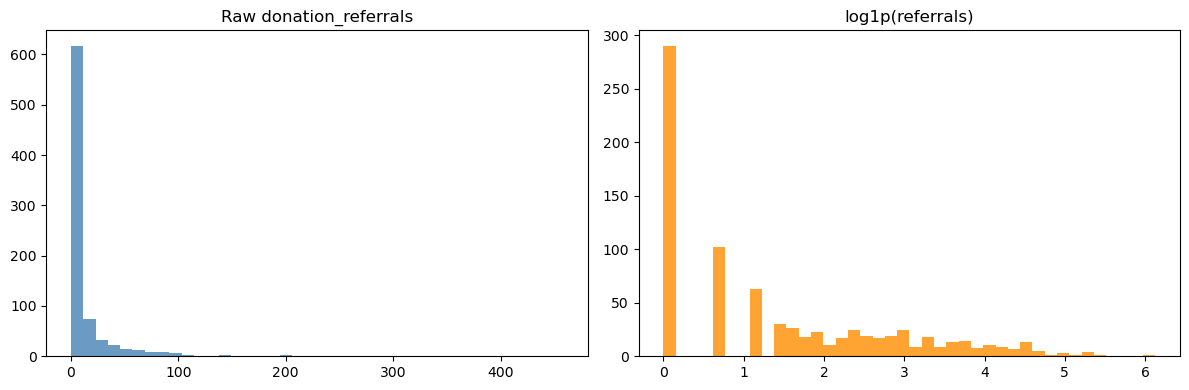

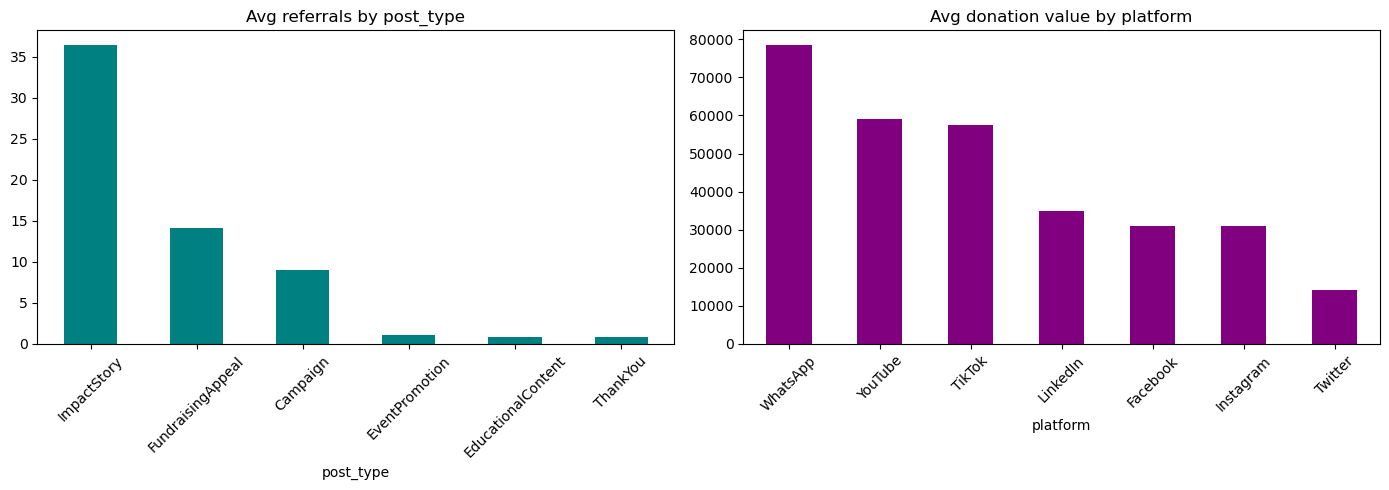

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['donation_referrals'], bins=40, color='steelblue', alpha=0.8)
axes[0].set_title('Raw donation_referrals')
axes[1].hist(df['log_referrals'], bins=40, color='darkorange', alpha=0.8)
axes[1].set_title('log1p(referrals)')
plt.tight_layout()
plt.show()

tmp1 = df.groupby('post_type', dropna=False)['donation_referrals'].mean().sort_values(ascending=False).head(12)
tmp2 = df.groupby('platform', dropna=False)['estimated_donation_value_php'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1,2, figsize=(14,5))
tmp1.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Avg referrals by post_type')
axes[0].tick_params(axis='x', rotation=45)
tmp2.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Avg donation value by platform')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [5]:
# FIXED_V3: Predictive modeling with explicit numeric matrix (no ColumnTransformer)
numeric_features = [
    'boost_budget_php', 'num_hashtags', 'caption_length', 'post_hour',
    'features_resident_story', 'campaign_active', 'is_peak_hour', 'is_weekend',
    'cta_is_donate', 'is_impact_story_share_combo', 'platform_is_whatsapp',
    'days_since_last_platform_post', 'has_call_to_action', 'is_boosted'
]

categorical_features = [
    'platform', 'post_type', 'media_type', 'sentiment_tone',
    'content_topic', 'call_to_action_type', 'day_of_week'
]

def build_model_matrix(frame: pd.DataFrame, fit_columns=None):
    m = frame[predictive_features].copy()

    for c in numeric_features:
        m[c] = pd.to_numeric(m[c], errors='coerce')
        med = m[c].median(skipna=True)
        if pd.isna(med):
            med = 0.0
        m[c] = m[c].replace([np.inf, -np.inf], np.nan).fillna(med)

    for c in categorical_features:
        m[c] = m[c].fillna('Missing').astype(str)

    m = pd.get_dummies(m, columns=categorical_features, drop_first=False, dtype=float)

    if fit_columns is not None:
        m = m.reindex(columns=fit_columns, fill_value=0.0)

    return m.astype(float)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=3),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

def eval_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return rmse, mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred)

y_model = pd.to_numeric(y, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0.0)

# random split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df[predictive_features], y_model, test_size=0.2, random_state=42
)
X_train = build_model_matrix(X_train_raw)
X_test = build_model_matrix(X_test_raw, fit_columns=X_train.columns)

rows = []
for n, m in models.items():
    model = m
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse, mae, r2 = eval_reg(y_test, pred)
    rows.append({
        'split': 'random_80_20',
        'model': n,
        'rmse_log': rmse,
        'mae_log': mae,
        'r2': r2,
        'rmse_backtransformed_approx': float(np.expm1(rmse))
    })
print(pd.DataFrame(rows).sort_values('rmse_log'))

# time split with fallback
if df['created_at'].notna().any():
    df_t = df.sort_values('created_at').reset_index(drop=True)
else:
    df_t = df.reset_index(drop=True).copy()

cut_idx = max(1, min(len(df_t) - 1, int(len(df_t) * 0.8)))
cut_dt = df_t.loc[cut_idx, 'created_at']

if pd.isna(cut_dt):
    train_t = df_t.iloc[:cut_idx].copy()
    test_t = df_t.iloc[cut_idx:].copy()
else:
    train_t = df_t[df_t['created_at'] < cut_dt].copy()
    test_t = df_t[df_t['created_at'] >= cut_dt].copy()
    if len(train_t) == 0 or len(test_t) == 0:
        train_t = df_t.iloc[:cut_idx].copy()
        test_t = df_t.iloc[cut_idx:].copy()

X_train_t = build_model_matrix(train_t[predictive_features])
X_test_t = build_model_matrix(test_t[predictive_features], fit_columns=X_train_t.columns)
y_train_t = pd.to_numeric(train_t['log_referrals'], errors='coerce').fillna(0.0)
y_test_t = pd.to_numeric(test_t['log_referrals'], errors='coerce').fillna(0.0)

time_rows = []
trained = {}
for n, m in models.items():
    model = m
    model.fit(X_train_t, y_train_t)
    pred = model.predict(X_test_t)
    rmse, mae, r2 = eval_reg(y_test_t, pred)
    time_rows.append({
        'split': 'time_80_20',
        'model': n,
        'rmse_log': rmse,
        'mae_log': mae,
        'r2': r2,
        'rmse_backtransformed_approx': float(np.expm1(rmse))
    })
    trained[n] = (model, X_train_t.columns.tolist())

time_df = pd.DataFrame(time_rows).sort_values('rmse_log')
print('time cutoff', cut_dt)
print(time_df)
BEST_MODEL_NAME = time_df.iloc[0]['model']
BEST_MODEL, BEST_MODEL_COLUMNS = trained[BEST_MODEL_NAME]
print('Selected predictive model:', BEST_MODEL_NAME)


          split             model  rmse_log   mae_log        r2  \
2  random_80_20  GradientBoosting  0.722769  0.576818  0.764740   
1  random_80_20      RandomForest  0.802197  0.609543  0.710192   
0  random_80_20  LinearRegression  0.847606  0.678124  0.676454   

   rmse_backtransformed_approx  
2                     1.060130  
1                     1.230436  
0                     1.334052  
time cutoff 2025-07-18 17:56:00
        split             model  rmse_log   mae_log        r2  \
2  time_80_20  GradientBoosting  0.736268  0.577242  0.769355   
1  time_80_20      RandomForest  0.819698  0.647074  0.714123   
0  time_80_20  LinearRegression  0.822640  0.650861  0.712067   

   rmse_backtransformed_approx  
2                     1.088129  
1                     1.269814  
0                     1.276503  
Selected predictive model: GradientBoosting


In [6]:
expl_cols = [
    'platform', 'post_type', 'media_type', 'sentiment_tone', 'content_topic',
    'has_call_to_action', 'call_to_action_type', 'is_boosted', 'boost_budget_php',
    'num_hashtags', 'caption_length', 'post_hour', 'is_weekend',
    'features_resident_story', 'campaign_active', 'cta_is_donate',
    'is_impact_story_share_combo', 'platform_is_whatsapp', 'days_since_last_platform_post'
]

expl = df[expl_cols + ['log_value']].copy()

# Explicit numeric vs categorical mapping
expl_numeric = [
    'has_call_to_action', 'is_boosted', 'boost_budget_php', 'num_hashtags',
    'caption_length', 'post_hour', 'is_weekend', 'features_resident_story',
    'campaign_active', 'cta_is_donate', 'is_impact_story_share_combo',
    'platform_is_whatsapp', 'days_since_last_platform_post'
]
expl_categorical = ['platform', 'post_type', 'media_type', 'sentiment_tone', 'content_topic', 'call_to_action_type']

for c in expl_numeric:
    if c not in expl.columns:
        expl[c] = np.nan
    expl[c] = pd.to_numeric(expl[c], errors='coerce')
    med = expl[c].median(skipna=True)
    if pd.isna(med):
        med = 0.0
    expl[c] = expl[c].replace([np.inf, -np.inf], np.nan).fillna(med)

for c in expl_categorical:
    if c not in expl.columns:
        expl[c] = 'Missing'
    expl[c] = expl[c].fillna('Missing').astype(str)

X_num = expl[expl_numeric].astype(float)
X_cat = pd.get_dummies(expl[expl_categorical], drop_first=True, dtype=float)
X_expl = pd.concat([X_num, X_cat], axis=1)
X_expl = sm.add_constant(X_expl, has_constant='add')
X_expl = X_expl.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)
y_expl = pd.to_numeric(expl['log_value'], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)

ols = sm.OLS(y_expl, X_expl).fit()
print(ols.summary())

coef = ols.params.drop('const', errors='ignore')
pvals = ols.pvalues.drop('const', errors='ignore')
coef_df = pd.DataFrame({'coef_log': coef, 'pvalue': pvals}).sort_values('coef_log', key=lambda s: s.abs(), ascending=False)
print('Top 3 associations with log donation value (associative):')
for idx, row in coef_df.head(3).iterrows():
    pct = (np.exp(row['coef_log']) - 1) * 100
    print(f"- {idx}: approx % effect={pct:.1f}%, p={row['pvalue']:.3f}")


                            OLS Regression Results                            
Dep. Variable:              log_value   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     27.00
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          5.57e-123
Time:                        12:03:45   Log-Likelihood:                -2069.7
No. Observations:                 812   AIC:                             4225.
Df Residuals:                     769   BIC:                             4428.
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [7]:
selection_table = pd.DataFrame({
    'feature': leakage_features,
    'decision': 'Dropped from predictive model',
    'reason': 'Post-publication leakage'
})
print(selection_table)
print('Kept predictive features:', predictive_features)


                      feature                       decision  \
0                 impressions  Dropped from predictive model   
1                       reach  Dropped from predictive model   
2                       likes  Dropped from predictive model   
3                    comments  Dropped from predictive model   
4                      shares  Dropped from predictive model   
5                       saves  Dropped from predictive model   
6              click_throughs  Dropped from predictive model   
7                 video_views  Dropped from predictive model   
8             engagement_rate  Dropped from predictive model   
9              profile_visits  Dropped from predictive model   
10         watch_time_seconds  Dropped from predictive model   
11  avg_view_duration_seconds  Dropped from predictive model   
12                   forwards  Dropped from predictive model   

                      reason  
0   Post-publication leakage  
1   Post-publication leakage  
2   Post-p

In [8]:
# --- Deployment Function (SQLite-backed) ---
import json
import sqlite3
from datetime import datetime
from pathlib import Path


def _deployment_db_path():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'ml-pipelines'
        if candidate.exists():
            return candidate / 'deployment_predictions.sqlite'
    return cwd / 'deployment_predictions.sqlite'


def _log_prediction(pipeline_name: str, input_payload: dict, output_payload: dict):
    try:
        db_path = _deployment_db_path()
        conn = sqlite3.connect(str(db_path))
        conn.execute("CREATE TABLE IF NOT EXISTS prediction_logs (id INTEGER PRIMARY KEY AUTOINCREMENT, pipeline TEXT NOT NULL, created_at TEXT NOT NULL, input_json TEXT NOT NULL, output_json TEXT NOT NULL)")
        cur = conn.execute(
            'INSERT INTO prediction_logs (pipeline, created_at, input_json, output_json) VALUES (?, ?, ?, ?)',
            (
                pipeline_name,
                datetime.utcnow().isoformat(timespec='seconds') + 'Z',
                json.dumps(input_payload, default=str),
                json.dumps(output_payload, default=str),
            )
        )
        conn.commit()
        conn.close()
        return int(cur.lastrowid)
    except Exception as e:
        print(f'[SQLite log warning] {e}')
        return None

FINAL_MODEL = BEST_MODEL
FINAL_FEATURES = predictive_features
FINAL_MODEL_COLUMNS = BEST_MODEL_COLUMNS


def _build_predict_row(input_data: dict):
    row = pd.DataFrame([{f: input_data.get(f, np.nan) for f in FINAL_FEATURES}])

    if pd.isna(row.loc[0, 'is_peak_hour']) and not pd.isna(row.loc[0, 'post_hour']):
        row.loc[0, 'is_peak_hour'] = int(int(float(row.loc[0, 'post_hour'])) in [8, 9, 10, 19, 20])
    if pd.isna(row.loc[0, 'is_weekend']) and isinstance(row.loc[0, 'day_of_week'], str):
        row.loc[0, 'is_weekend'] = int(row.loc[0, 'day_of_week'] in ['Saturday', 'Sunday'])

    return build_model_matrix(row, fit_columns=FINAL_MODEL_COLUMNS)


def predict_social_referrals(input_data: dict):
    X_row = _build_predict_row(input_data)
    pred_log = float(FINAL_MODEL.predict(X_row)[0])
    pred_raw = max(0.0, float(np.expm1(pred_log)))
    result = {
        'predicted_log_referrals': round(pred_log, 4),
        'predicted_referrals': round(pred_raw, 2)
    }
    result['prediction_log_id'] = _log_prediction('social-media-donation-conversion', input_data, result)
    return result


example_post = {
    'platform': 'Facebook', 'post_type': 'ImpactStory', 'media_type': 'Video', 'sentiment_tone': 'Hopeful',
    'content_topic': 'ChildRecovery', 'has_call_to_action': True, 'call_to_action_type': 'DonateNow',
    'is_boosted': True, 'boost_budget_php': 1500, 'num_hashtags': 6, 'caption_length': 280, 'post_hour': 20,
    'day_of_week': 'Friday', 'features_resident_story': True, 'campaign_active': 1, 'is_peak_hour': 1,
    'is_weekend': 0, 'cta_is_donate': 1, 'is_impact_story_share_combo': 0, 'platform_is_whatsapp': 0,
    'days_since_last_platform_post': 1
}
print(predict_social_referrals(example_post))


{'predicted_log_referrals': 4.4309, 'predicted_referrals': 83.01, 'prediction_log_id': 5}


/var/folders/qz/53nwhbc948793tv0wzxhp4880000gn/T/ipykernel_4993/2447282032.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat(timespec='seconds') + 'Z',


## Data Acquisition, Preparation & Exploration

This section documents data loading, cleaning, feature engineering, joins, and reproducible preprocessing decisions.


## Modeling & Feature Selection

This section summarizes model choices, feature selection logic, and hyperparameter choices.


## Evaluation & Interpretation

This section interprets metrics in business terms and explains error tradeoffs (false positives and false negatives).


## Causal and Relationship Analysis

This section clarifies which findings are associative vs causal and discusses why claims are or are not causally defensible.


## Deployment Notes

Current status: model logic is notebook-ready.

Use `predict_social_referrals(...)` inside a social planning workflow. Website target: Reports & Analytics (or a dedicated planning page) where staff input draft post details and see predicted donation referrals before publishing.

Web/API integration is pending and should be connected to dashboard and endpoint routes in the application repo.


### Error Tradeoff Note (FP/FN)

For referral forecasting, overprediction can cause over-allocation of campaign resources, while underprediction can hide high-opportunity posts. Use predictions as planning signals, not strict guarantees, especially with zero-heavy referral data.


### Hyperparameter Tuning Notes

Multiple algorithms are compared (linear, random forest, gradient boosting), with selection based on out-of-sample RMSE under random and time-based splits.


### Fairness Check Notes

Fairness check recommendation: monitor whether model recommendations systematically favor certain platforms/content types due to historical posting volume imbalances.


### Validation Rationale

Validation strategy is matched to data structure and sample size (e.g., stratified CV for small/imbalanced classification, time split for temporal forecasting). This avoids leakage and gives realistic out-of-sample estimates.


### Monitoring Plan

Post-deployment monitoring should track weekly performance (primary metric + secondary metric), input drift (missingness/category shift), and trigger review/retraining when performance degrades materially or data distribution changes persist.


### Final Decision Recommendation

Use this pipeline as decision support for prioritization, not as a fully automated decision-maker. Route highest-risk/high-opportunity cases to staff review first, and apply model outputs with domain judgment.


### Limitations and Ethics/Fairness

Results are observational and may encode historical process biases. Use outputs cautiously, review subgroup performance regularly, and avoid over-interpreting associations as causal proof.


### Cross-Pipeline Metrics Summary (Presentation Table)

Use the table below in presentation materials. Update values after final reruns.


In [9]:
# Auto-populated presentation summary (robust metric extraction)
def _best_from_table(df, want='max'):
    if df is None or not hasattr(df, 'columns') or len(df) == 0:
        return np.nan
    cols = {c.lower(): c for c in df.columns}

    primary_candidates = ['recall','recall_mean','mean_recall','rmse','rmse_log','rmse_log_mean','auc','auc_mean','roc_auc','f1','f1_mean','r2','r2_mean']
    picked = np.nan
    picked_col = None

    # try to find first present metric column
    for k in primary_candidates:
        if k in cols:
            picked_col = cols[k]
            break
    if picked_col is None:
        return np.nan

    s = pd.to_numeric(df[picked_col], errors='coerce')
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        return np.nan

    if 'rmse' in picked_col.lower():
        return float(s.min())
    return float(s.max())

def _extract_metrics(primary_pref='recall', secondary_pref='auc'):
    primary = np.nan
    secondary = np.nan

    # 1) Search scalar globals first
    for name, val in globals().items():
        lname = str(name).lower()
        if np.isnan(primary) and primary_pref in lname and isinstance(val, (int, float, np.number)):
            primary = float(val)
        if np.isnan(secondary) and secondary_pref in lname and isinstance(val, (int, float, np.number)):
            secondary = float(val)

    # 2) Search DataFrame globals for matching columns
    if np.isnan(primary) or np.isnan(secondary):
        for name, obj in globals().items():
            if hasattr(obj, 'columns') and hasattr(obj, '__len__'):
                cols = {c.lower(): c for c in obj.columns}
                if np.isnan(primary):
                    for k in [primary_pref, f'{primary_pref}_mean', f'mean_{primary_pref}']:
                        if k in cols:
                            s = pd.to_numeric(obj[cols[k]], errors='coerce').dropna()
                            if len(s):
                                primary = float(s.min() if 'rmse' in k else s.max())
                                break
                if np.isnan(secondary):
                    for k in [secondary_pref, f'{secondary_pref}_mean', f'mean_{secondary_pref}', 'roc_auc']:
                        if k in cols:
                            s = pd.to_numeric(obj[cols[k]], errors='coerce').dropna()
                            if len(s):
                                secondary = float(s.min() if 'rmse' in k else s.max())
                                break

    # 3) Last resort: any results-like DataFrame
    if np.isnan(primary) or np.isnan(secondary):
        for name, obj in globals().items():
            lname = str(name).lower()
            if ('result' in lname or 'summary' in lname or 'time_df' in lname or 'comparison' in lname) and hasattr(obj, 'columns'):
                fallback = _best_from_table(obj)
                if np.isnan(primary):
                    primary = fallback
                elif np.isnan(secondary):
                    secondary = fallback
                if not np.isnan(primary) and not np.isnan(secondary):
                    break

    return primary, secondary

primary, secondary = _extract_metrics(primary_pref='rmse_log', secondary_pref='r2')

summary_row = {
    'pipeline': 'social-media-donation-conversion',
    'primary_metric': primary,
    'secondary_metric': secondary,
    'notes': 'Primary=RMSE(log, lower better), Secondary=R2'
}
summary_df = pd.DataFrame([summary_row])
print(summary_df)


                           pipeline  primary_metric  secondary_metric  \
0  social-media-donation-conversion        0.736268          0.769355   

                                           notes  
0  Primary=RMSE(log, lower better), Secondary=R2  
